<h4>Import Libraries </h4>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

<h4> Load Dataset </h4>

In [2]:
df = pd.read_csv("Fraud.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

<h4> Data Cleaning </h4>

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<h4> Drop unnecessary columns </h4>

In [9]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0


<h4> Feature Engineering </h4>

In [10]:
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

df['error_balance'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,error_balance
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,1.455192e-11
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,-1.136868e-12
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.000000e+00
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,0.000000e+00
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,0.000000e+00
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.000000e+00
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,0.000000e+00
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.000000e+00


In [11]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,error_balance,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,1.455192e-11,False,False,True,False
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,-1.136868e-12,False,False,True,False
2,1,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.000000e+00,False,False,False,True
3,1,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,0.000000e+00,True,False,False,False
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.000000e+00,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,0.000000e+00,True,False,False,False
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.000000e+00,False,False,False,True
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,0.000000e+00,True,False,False,False
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.000000e+00,False,False,False,True


<h4> Correlation check </h4>

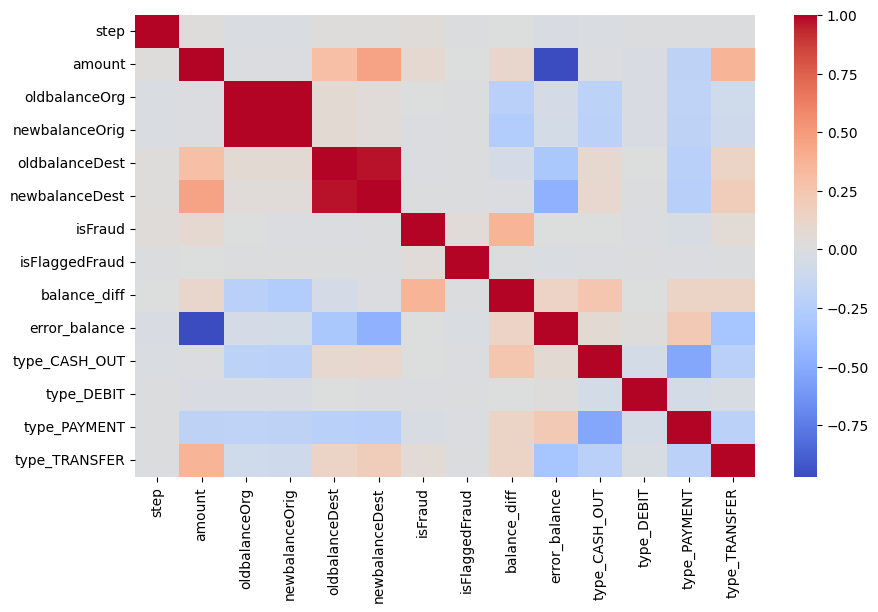

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

<h4> Split Data </h4>

In [13]:
df_sample = df.sample(n=100000, random_state=42) 

In [14]:
X = df_sample.drop('isFraud', axis=1)
y = df_sample['isFraud']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

<h4> Model Building </h4>

In [16]:
model = RandomForestClassifier(n_estimators=20, n_jobs=-1, random_state=42)


In [17]:
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h4> Prediction </h4>

In [18]:
y_pred = model.predict(X_test)

<h4> Model Evaluation </h4>

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19973
           1       1.00      1.00      1.00        27

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Confusion Matrix:

[[19973     0]
 [    0    27]]


<h4> Feature Importance </h4>

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

           Feature  Importance
7     balance_diff    0.258485
3   newbalanceOrig    0.253275
8    error_balance    0.100280
5   newbalanceDest    0.094414
1           amount    0.084306
2    oldbalanceOrg    0.073497
12   type_TRANSFER    0.046352
0             step    0.043835
4   oldbalanceDest    0.028656
11    type_PAYMENT    0.006072


<h4> Visualization </h4>
<h4> Fraud vs Non-Fraud Distribution </h4>

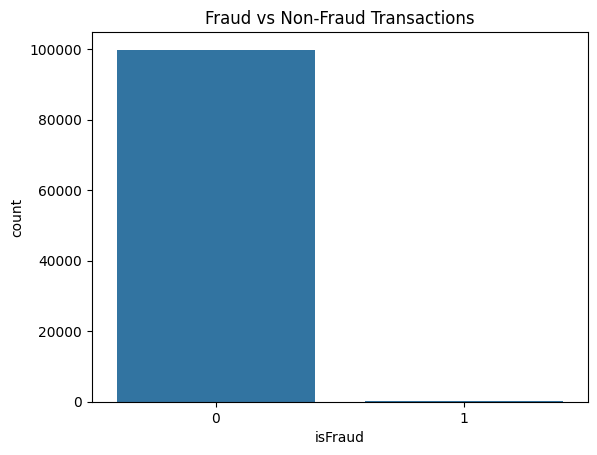

In [21]:
sns.countplot(x='isFraud', data=df_sample)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

<h4> Amount Distribution</h4>

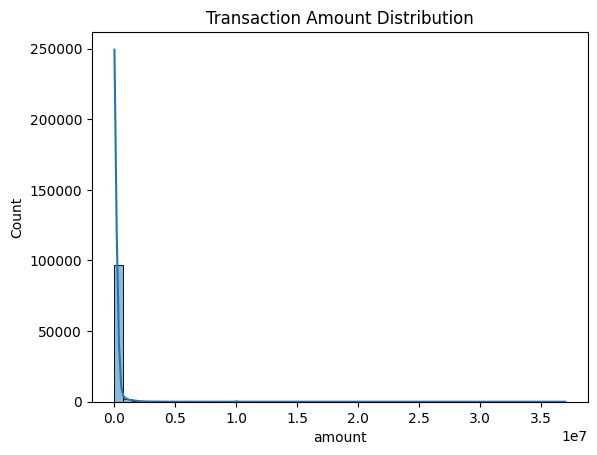

In [26]:
sns.histplot(df_sample['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

<h4> Fraud Amount Comparison </h4>

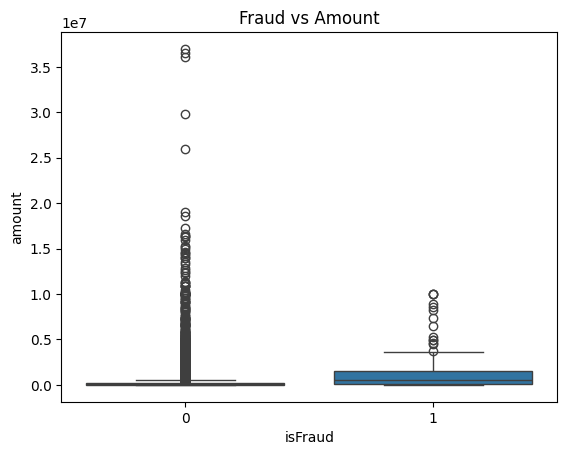

In [27]:
sns.boxplot(x='isFraud', y='amount', data=df_sample)
plt.title("Fraud vs Amount")
plt.show()

<h4> Fraud Over Time </h4>

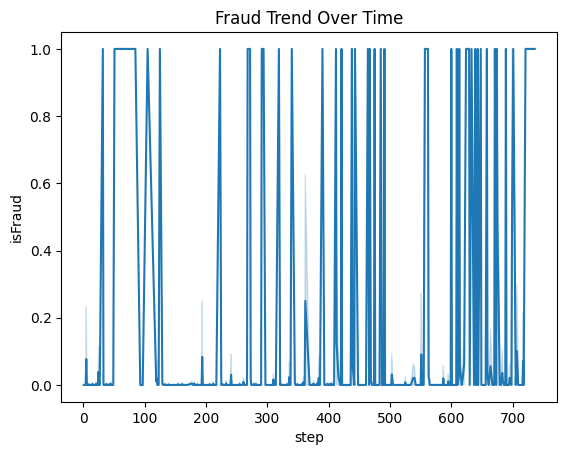

In [28]:
sns.lineplot(x='step', y='isFraud', data=df_sample)
plt.title("Fraud Trend Over Time")
plt.show()

<h4> Fraud vs Balance </h4>

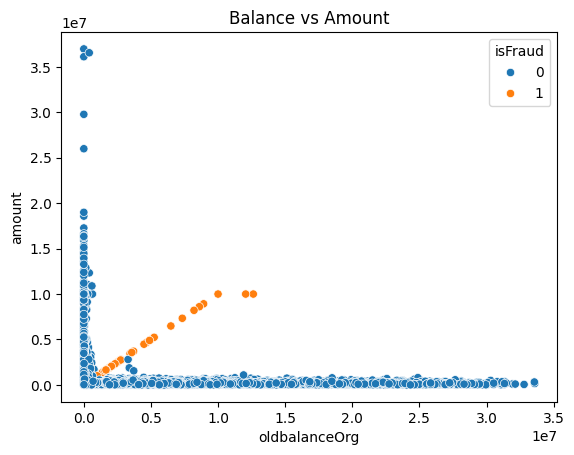

In [29]:
sns.scatterplot(x='oldbalanceOrg', y='amount', hue='isFraud', data=df_sample)
plt.title("Balance vs Amount")
plt.show()